## Reto de la semana 5
Diego Andrés Burbano A.

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
from google.colab import drive, files

%matplotlib inline

In [ ]:
# Montaje del drive
drive.mount('/content/drive', force_remount=True)
os.chdir('/content/drive/MyDrive/datos')

data = pd.read_csv('./BreastCancer.csv', sep=',')

Mounted at /content/drive


In [ ]:
data.head()

,radius_mean,smoothness_mean,pronostic
0,0.950308,1.523620,1
1,1.646970,-0.893636,1
2,1.409349,0.891658,1
3,-0.823748,3.254336,1
4,1.571363,0.223788,1


In [ ]:
data.shape

(469, 3)

In [ ]:
# a) Definir la función para calcular f(w)
def calcular_f(w, data):
    X = data.iloc[:, :-1].values
    t = data.iloc[:, -1].values
    m = len(t)
    f_w = 0
    for i in range(m):
        z_i = np.append(X[i], 1)
        y_i = 1 / (1 + np.exp(-np.dot(w, z_i)))
        f_w += t[i] * np.log(y_i) + (1 - t[i]) * np.log(1 - y_i)

    f_w = -f_w / m
    return f_w

# Definimos los límites:
boundaries = [(None, None), (None, None), (None, None)]

# Condiciones iniciales
x0 = [0, 0, 0]
trayectoria = []

# Función callback que guarda cada w explorado
def callback(w):
    trayectoria.append(w)

# Ejecutamos minimize sin restricciones
res = minimize(calcular_f, x0, args=(data,), bounds=boundaries, callback = callback)

print("Resultado final:")
print(res)

Resultado final:
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 0.20464127038690735
        x: [ 5.359e+00  1.641e+00  2.444e-01]
      nit: 12
      jac: [ 1.332e-07 -8.049e-08 -1.388e-08]
     nfev: 56
     njev: 14
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>


In [ ]:
# Mostrar historial de w
print("\nHistorial de w explorados:")
for i, w in enumerate(trayectoria):
    print(f"Iteración {i + 1}: w = {w}")


Historial de w explorados:
Iteración 1: w = [ 0.88552475  0.44979476 -0.11632105]
Iteración 2: w = [ 1.65773283  0.64663465 -0.17735685]
Iteración 3: w = [ 2.45210659  0.90132478 -0.05971597]
Iteración 4: w = [ 3.32498034  1.04246498 -0.13485471]
Iteración 5: w = [4.28931262 1.52881482 0.31149222]
Iteración 6: w = [4.79719201 1.52550508 0.2359392 ]
Iteración 7: w = [5.15718975 1.58500517 0.22125683]
Iteración 8: w = [5.31484167 1.62531108 0.23282381]
Iteración 9: w = [5.35786972 1.6357375  0.24430523]
Iteración 10: w = [5.35991861 1.64099812 0.24279948]
Iteración 11: w = [5.35962133 1.64130686 0.244143  ]
Iteración 12: w = [5.35902853 1.64129491 0.2444218 ]


In [ ]:
# Almacenamos en la variable 'mejor_w' el mejor punto que arroja el minimizador
print("Mejor valor de w encontrado:")
mejor_w = res.x
print(mejor_w)

Mejor valor de w encontrado:
[5.35902853 1.64129491 0.2444218 ]


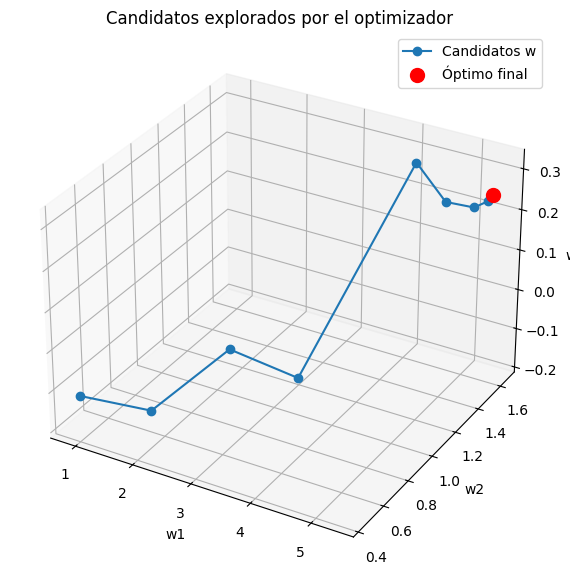

In [ ]:
trayectoria = np.array(trayectoria)
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(trayectoria[:, 0], trayectoria[:, 1], trayectoria[:, 2], marker='o', label='Candidatos w')
ax.scatter(trayectoria[-1, 0], trayectoria[-1, 1], trayectoria[-1, 2], color='red', s=100, label='Óptimo final')

ax.set_xlabel('w1')
ax.set_ylabel('w2')
ax.set_zlabel('w3')
ax.set_title('Candidatos explorados por el optimizador')
ax.legend()
plt.show()

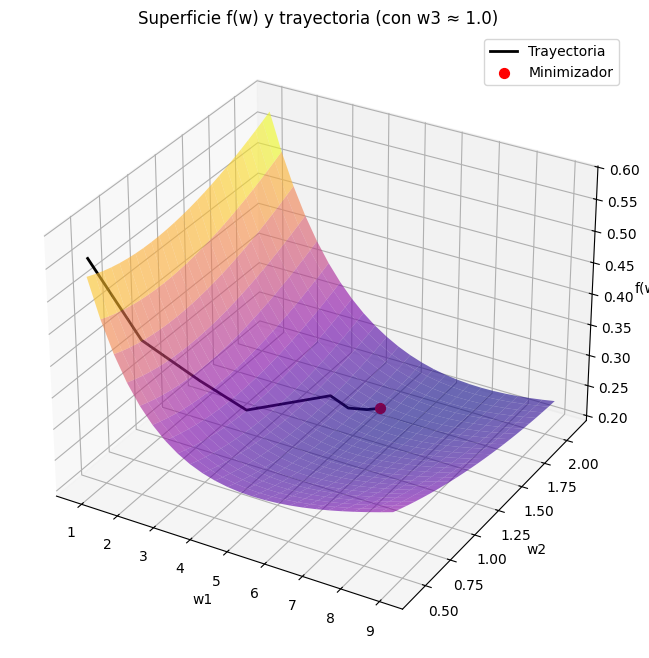

In [ ]:
trayectoria = np.array(trayectoria)
w3_fijo = 1.0

# Definimos la malla de valores de w1 y w2
w1_range = np.linspace(1, 9, 25)
w2_range = np.linspace(0.4, 2.1, 25)
W1, W2 = np.meshgrid(w1_range, w2_range)
Z = np.zeros_like(W1)

# Calculamos f(w) sobre la grilla con w3 fijo
for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        w = np.array([W1[i, j], W2[i, j], w3_fijo])
        Z[i, j] = calcular_f(w, data)

# Graficamos la superficie
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W1, W2, Z, cmap='plasma', alpha=0.6)

# Trayectoria proyectada (usamos solo los puntos con w3 cercano al fijo)
tray_filt = trayectoria[np.abs(trayectoria[:, 2] - w3_fijo) < 2]
if len(tray_filt) > 0:
    f_vals = [calcular_f([w[0], w[1], w3_fijo], data) for w in tray_filt]
    ax.plot(tray_filt[:, 0], tray_filt[:, 1], f_vals, color='black', linewidth=2, label='Trayectoria')
    ax.scatter(tray_filt[-1, 0], tray_filt[-1, 1], f_vals[-1], color='red', s=50, label='Minimizador')

ax.set_xlabel('w1')
ax.set_ylabel('w2')
ax.set_zlabel('f(w)')
ax.set_title(f'Superficie f(w) y trayectoria (con w3 ≈ {w3_fijo})')
ax.legend()
plt.show()


In [ ]:
def calcular_gradiente(w, data):
    # Extraer características y etiquetas
    X = data.iloc[:, :-1].values
    t = data.iloc[:, -1].values

    m = len(t)
    n = len(w)
    grad = np.zeros(n)

    for i in range(m):
        z_i = np.append(X[i], 1)
        y_i = 1 / (1 + np.exp(-np.dot(w, z_i)))
        y_i = np.clip(y_i, 1e-15, 1 - 1e-15)

        # Gradiente
        grad += (y_i - t[i]) * z_i


    grad = grad / m

    return grad

grad_mejor_w = calcular_gradiente(mejor_w, data)
print("Gradiente mejor w encontrado:\n", grad_mejor_w)

Gradiente mejor w encontrado:
 [ 1.32111952e-07 -6.61893471e-08  1.31362700e-08]


In [ ]:
# Creación de un arreglo que contiene los gradientes de los 12 candidatos o iteraciones encontradas:
arreglo_gradientes = []
for i in range(len(trayectoria)):
  grad_i = calcular_gradiente(trayectoria[i], data)
  arreglo_gradientes.append(grad_i)

arreglo_gradientes = np.array(arreglo_gradientes)

# Creación de un arreglo que contiene las normas de los 12 gradientes calculados:
def calcular_norma(gradiente):
    return np.linalg.norm(gradiente, ord=2)

arreglo_normas = np.array([calcular_norma(grad_j) for grad_j in arreglo_gradientes])
print(arreglo_normas)


[1.79871790e-01 9.07085109e-02 4.61167957e-02 2.65752102e-02
 2.37339509e-02 6.57038302e-03 1.24177765e-03 5.98900160e-04
 3.01640300e-04 1.26777346e-04 2.72578961e-05 1.48348101e-07]


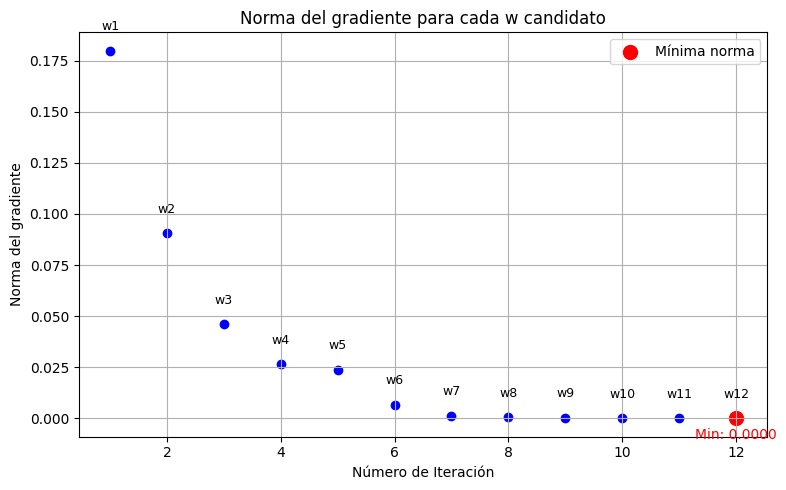

In [ ]:
# Gráfica de las normas de los gradientes:

indices = np.arange(1, len(arreglo_normas) + 1)  # Índices del 1 al 12

plt.figure(figsize=(8, 5))
plt.scatter(indices, arreglo_normas, color='blue', marker='o')

# Se etiqueta cada punto con 'w1', 'w2', ..., 'w12'
for i, norma in zip(indices, arreglo_normas):
    plt.text(i, norma + 0.01, f"w{i}", ha='center', fontsize=9)

# Encontrar el índice con la menor norma
min_index = np.argmin(arreglo_normas)
min_valor = arreglo_normas[min_index]
min_index_grafico = min_index + 1
plt.scatter(min_index_grafico, min_valor, color='red', s=100, label='Mínima norma')
plt.annotate(f"Min: {min_valor:.4f}",
             (min_index_grafico, min_valor),
             textcoords="offset points",
             xytext=(0, -15),
             ha='center',
             color='red')

plt.xlabel("Número de Iteración")
plt.ylabel("Norma del gradiente")
plt.title("Norma del gradiente para cada w candidato")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Cálculo de la matriz hessiana para el mejor_w encontrado
def calcular_hessiana(w, data):
    # Extraer características y etiquetas
    X = data.iloc[:, :-1].values
    t = data.iloc[:, -1].values

    m = len(t)
    n = len(w)
    hess = np.zeros((n, n))

    for i in range(m):
        z_i = np.append(X[i], 1)
        y_i = 1 / (1 + np.exp(-np.dot(w, z_i)))
        y_i = np.clip(y_i, 1e-15, 1 - 1e-15)
        hess += y_i * (1 - y_i) * np.outer(z_i, z_i)
    hess = hess / m
    return hess

hess_mejor_w = calcular_hessiana(mejor_w, data)
print("Matriz Hessiana mejor w encontrado:\n", hess_mejor_w)

Matriz Hessiana mejor w encontrado:
 [[ 0.01005922 -0.01356702 -0.01039308]
 [-0.01356702  0.05477348  0.00994813]
 [-0.01039308  0.00994813  0.06329683]]


In [ ]:
# Test de positividad de la matriz hessiana para el mejor_w:
def test_positividad(M):
  vals ,vec =np.linalg.eig(M)
  if all(val > 0 for val in vals):
    resp="Positiva definida"
  elif all(val >= 0 for val in vals):
    resp="Positiva semidefinida"
  elif all(val < 0 for val in vals):
    resp="Negativa definida"
  elif all(val <= 0 for val in vals):
    resp="Negativa semidefinida"
  else:
    resp="Indefinida"
  return (resp)

print("Test de positividad para la matriz hessiana del mejor w encontrado:\n", test_positividad(calcular_hessiana(mejor_w, data)))

Test de positividad para la matriz hessiana del mejor w encontrado:
 Positiva definida


In [ ]:
# Condición necesaria de primer orden:
def prueba_gradiente(gradiente, punto, umbral=1e-6):
    norma_gradiente = np.linalg.norm(gradiente)

    # Verificar si la norma del gradiente está dentro del umbral de tolerancia
    if norma_gradiente < umbral:
        print("La condición de primer orden se cumple.")
    else:
        print("La condición de primer orden no se cumple.")

gradiente = np.array(grad_mejor_w)
punto = mejor_w

prueba_gradiente(gradiente, punto)

La condición de primer orden se cumple.


Por lo tanto mejor_w es un potencial minimizador del problema.

In [ ]:
# Condición suficiente de segundo orden:
def prueba_hessiana(hessiana, punto):
    # Evaluar los eigenvalores de la matriz hessiana
    eigenvalores = np.linalg.eigvals(hessiana)

    # Verificar si todos los eigenvalores son positivos
    if all(val > 0 for val in eigenvalores):
        print("La matriz hessiana evaluada en el punto es positiva definida.")
    else:
        print("La matriz hessiana evaluada en el punto no es positiva definida.")

punto = mejor_w
hessiana = np.array(hess_mejor_w)
prueba_hessiana(hessiana, punto)

La matriz hessiana evaluada en el punto es positiva definida.


Por lo tanto, tenemos la seguridad que mejor_w es un minimizador local, gracias a la condición suficiente de segundo orden.

**Demostración que f(w) es convexa para R3:**

Para demostrar que f(w) es convexa para todo R3, debemos demostrar que la matriz Hessiana es positiva semidefinida para todo x que forma parte de R3.

La matriz Hessiana de f(w) corresponde a:

\begin{equation}
\nabla^2 f(w) = \frac{1}{m} \sum_{i=1}^{m} y_i (1 - y_i) \, z^{(i)} {z^{(i)}}^T
\end{equation}

La matriz es una suma de matrices semidefinidas positivas, lo cual se puede demostrar analizando cada término en la suma:
Primer término:

\begin{equation}
z^{(i)} {z^{(i)}}^T
\end{equation}

Para cualquier vector real z, el producto $$z.z^T$$ genera una matriz semidefinida positiva. Esto se demuestra observando que, para cualquier vector v que pertenece a R3 se tiene: $$ v^T(z.z^T)v = (v^Tz)(z^Tv) = (z^Tv)^2 >= 0 $$ por lo tanto nunca puede ser negativa.

De otro lado, analizando el segundo termino correspondiente al escalar $$y_i (1 - y_i)$$ siempre es mayor que cero, puesto que la función logística siempre da valores estrictamente entre 0 y 1. Esta función se maximiza cuando y = 0.5 por lo tanto, $$ 0 < y_i ( 1 - y_1) < 0.25$$ Por lo tanto es un escalar positivo.

Con lo anterior concluimos que la cada término de la forma:
\begin{equation}
y_i (1 - y_i) \, z^{(i)} {z^{(i)}}^T
\end{equation}
es semidefinido positivo, porque es el producto de un escalar positivo con una matriz semidefinida positiva, y la suma de matrices semidefinidas positivas da como resultado una matriz semidefinida positiva.
Habiendo demostrado que la matriz Hessiana es positiva semidefinida para todo x en R3, concluimos que f(w) es convexa en R3.

## **Conclusiones**:

*   El punto por evaluar w (mejor_w) es un punto interior de R3 (toda la región factible).
*   El problema de optimización es un problema convexo, según se demostró en el punto inmediatamente anterior.
*   El punto w (mejor_w) satisface la condición que el gradiente de la función f(w) es cero
*   Habiendo cumplido las condiciones necesarias y suficientes caso convexo, podemos concluir que mejor_w es un minimizador GLOBAL de f sobre R3.

